In [ ]:
!unzip "/content/drive/MyDrive/DATASETS/oral dataset.zip"

Archive:  /content/drive/MyDrive/DATASETS/oral dataset.zip
   creating: oral dataset/
   creating: oral dataset/Calculus/
  inflating: oral dataset/Calculus/(1).jpg  
  inflating: oral dataset/Calculus/(10).jpg  
  inflating: oral dataset/Calculus/(100).jpg  
  inflating: oral dataset/Calculus/(1000).jpg  
  inflating: oral dataset/Calculus/(1001).jpg  
  inflating: oral dataset/Calculus/(1002).jpg  
  inflating: oral dataset/Calculus/(1003).jpg  
  inflating: oral dataset/Calculus/(1004).jpg  
  inflating: oral dataset/Calculus/(1005).jpg  
  inflating: oral dataset/Calculus/(1006).jpg  
  inflating: oral dataset/Calculus/(1007).jpg  
  inflating: oral dataset/Calculus/(1008).jpg  
  inflating: oral dataset/Calculus/(1009).jpg  
  inflating: oral dataset/Calculus/(101).jpg  
  inflating: oral dataset/Calculus/(1010).jpg  
  inflating: oral dataset/Calculus/(1011).jpg  
  inflating: oral dataset/Calculus/(1012).jpg  
  inflating: oral dataset/Calculus/(1013).jpg  
  inflating: oral dat

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import pathlib

In [ ]:
DATA_DIR = "/content/oral dataset"
IMG_SIZE = (224,224,3)
EPOCHES = 50
BATCH_SIZE = 32

In [ ]:
train_ds=image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE[0], IMG_SIZE[1]),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)
val_ds=image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE[0], IMG_SIZE[1]),
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

Found 4375 files belonging to 6 classes.
Using 3500 files for training.
Found 4375 files belonging to 6 classes.
Using 875 files for validation.


In [ ]:
class_names = train_ds.class_names
class_names

['Calculus',
 'Hypodontia',
 'Mouth ulcer',
 'Normal',
 'caries',
 'tooth discoloration']

In [ ]:
from tensorflow.keras.applications import EfficientNetV2B3

In [ ]:
efficientnet_base = EfficientNetV2B3(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
model_efficientnet = Sequential([
    tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),

    tf.keras.layers.Lambda(tf.keras.applications.efficientnet.preprocess_input),

    efficientnet_base,

    tf.keras.layers.GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

In [ ]:
efficientnet_base.trainable = False

In [ ]:
model_efficientnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model_efficientnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 7, 7, 1536)     │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,128,132 (50.08 MB)

 Trainable params: 197,510 (771.52 KB)

 Non-trainable params: 12,930,622 (49.33 MB)

In [ ]:
history = model_efficientnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35
)

Epoch 1/35
110/110 ━━━━━━━━━━━━━━━━━━━━ 52s 249ms/step - accuracy: 0.4817 - loss: 1.3866 - val_accuracy: 0.6709 - val_loss: 1.0423
Epoch 2/35
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 177ms/step - accuracy: 0.6466 - loss: 1.0336 - val_accuracy: 0.7463 - val_loss: 0.8214
Epoch 3/35
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 193ms/step - accuracy: 0.7206 - loss: 0.8669 - val_accuracy: 0.7806 - val_loss: 0.6978
Epoch 4/35
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 180ms/step - accuracy: 0.7546 - loss: 0.7490 - val_accuracy: 0.8080 - val_loss: 0.6113
Epoch 5/35
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 184ms/step - accuracy: 0.7789 - loss: 0.6993 - val_accuracy: 0.8149 - val_loss: 0.5643
Epoch 6/35
110/110 ━━━━━━━━━━━━━━━━━━━━ 21s 187ms/step - accuracy: 0.7917 - loss: 0.6367 - val_accuracy: 0.8263 - val_loss: 0.5225
Epoch 7/35
110/110 ━━━━━━━━━━━━━━━━━━━━ 20s 176ms/step - accuracy: 0.8114 - loss: 0.5998 - val_accuracy: 0.8229 - val_loss: 0.5013
Epoch 8/35
110/110 ━━━━━━━━━━━━━━━━━━━━ 26s 235ms/step - accuracy: 0.8097 - loss: 0

In [ ]:
efficientnet_base.trainable = True

In [ ]:
model_efficientnet.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model_efficientnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 7, 7, 1536)     │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,128,132 (50.08 MB)

 Trainable params: 13,018,916 (49.66 MB)

 Non-trainable params: 109,216 (426.62 KB)

In [ ]:
history_fine_tune = model_efficientnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHES,
    initial_epoch=35
)

Epoch 36/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 142s 600ms/step - accuracy: 0.6474 - loss: 1.0459 - val_accuracy: 0.7257 - val_loss: 0.7963
Epoch 37/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 73s 542ms/step - accuracy: 0.7529 - loss: 0.7827 - val_accuracy: 0.7920 - val_loss: 0.6383
Epoch 38/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 82s 538ms/step - accuracy: 0.8034 - loss: 0.6416 - val_accuracy: 0.8343 - val_loss: 0.5289
Epoch 39/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 59s 534ms/step - accuracy: 0.8369 - loss: 0.5417 - val_accuracy: 0.8537 - val_loss: 0.4667
Epoch 40/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 60s 542ms/step - accuracy: 0.8523 - loss: 0.4884 - val_accuracy: 0.8651 - val_loss: 0.4162
Epoch 41/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 59s 532ms/step - accuracy: 0.8706 - loss: 0.4245 - val_accuracy: 0.8914 - val_loss: 0.3642
Epoch 42/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 60s 543ms/step - accuracy: 0.8820 - loss: 0.3953 - val_accuracy: 0.9006 - val_loss: 0.3372
Epoch 43/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 59s 533ms/step - accuracy: 0.8911 

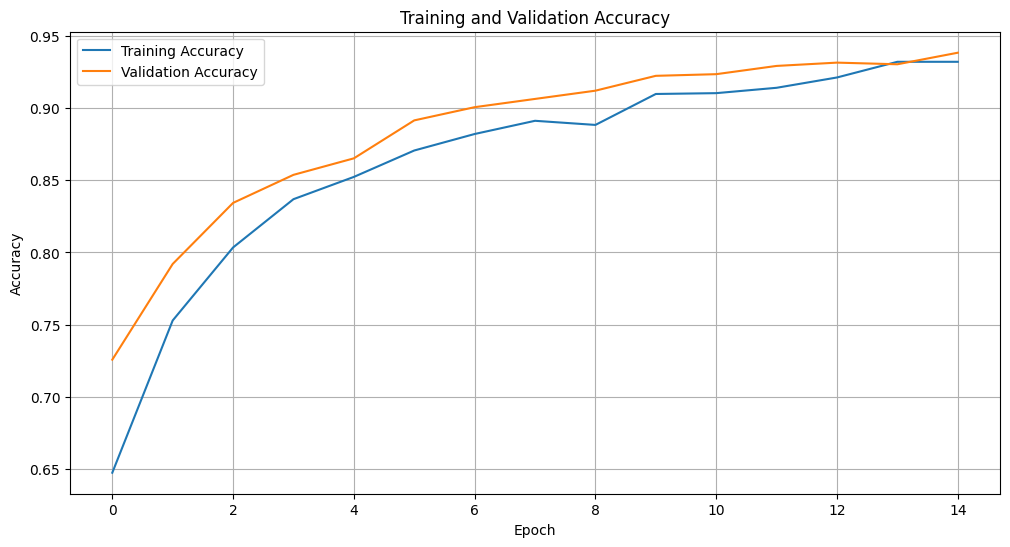

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(history_fine_tune.history['accuracy'], label='Training Accuracy')
plt.plot(history_fine_tune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('training curve efficientnet OD.png')
plt.show()

In [ ]:
model_efficientnet.save('ORAL_DISEASES_MODEL.keras')

In [ ]:
model2 = tf.keras.models.load_model(
    '/content/ORAL_DISEASES_MODEL.keras',
    custom_objects={'preprocess_input': tf.keras.applications.efficientnet.preprocess_input}
)
print("Model loaded successfully.\n")

Model loaded successfully.



In [ ]:
print("Generating predictions...")
true_labels = []
predicted_labels = []


for images, labels in val_ds:
    preds = model2.predict(images, verbose=0)


    true_labels.extend(np.argmax(labels.numpy(), axis=1))
    predicted_labels.extend(np.argmax(preds, axis=1))

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

Generating predictions...


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

print("--- Classification Report ---")
report = classification_report(true_labels, predicted_labels, target_names=class_names, labels=np.arange(len(class_names)))
print(report)


fig = plt.figure(figsize=(10, len(class_names) * 0.5 + 2))
ax = fig.add_subplot(111)
ax.text(0.01, 0.05, report, {'fontsize': 12}, fontproperties = 'monospace')
ax.axis('off')
ax.set_title('Classification Report', fontsize=14, loc='left')
plt.tight_layout()
plt.savefig('classification_report_OD.png')
plt.close(fig)

--- Classification Report ---
                     precision    recall  f1-score   support

           Calculus       0.90      1.00      0.95       261
         Hypodontia       0.98      0.95      0.97       220
        Mouth ulcer       0.94      0.93      0.93        54
             Normal       0.92      0.91      0.91        74
             caries       0.85      0.48      0.61        48
tooth discoloration       0.96      0.96      0.96       218

           accuracy                           0.94       875
          macro avg       0.93      0.87      0.89       875
       weighted avg       0.94      0.94      0.93       875



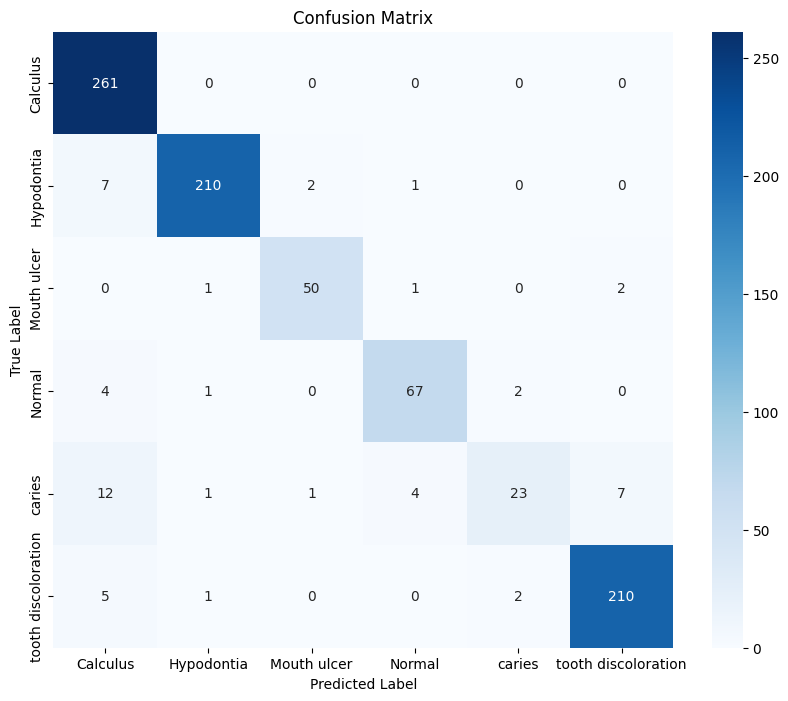

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(true_labels, predicted_labels, labels=np.arange(len(class_names)))


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix_OD.png')
plt.show()